# 👥 客户分析

**目标**：分析不同客户类型（Segment）的消费行为，识别核心客户群体

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 设置 seaborn 样式
sns.set_style('whitegrid')
sns.set_palette('husl')

print('库加载完成！')

库加载完成！


In [2]:
# 加载数据
df = pd.read_csv('../data/processed/superstore_cleaned.csv')

# 转换日期列
df['Order Date'] = pd.to_datetime(df['Order Date'])

print(f'数据加载成功！共 {len(df)} 条记录')

数据加载成功！共 9994 条记录


## 1. 客户类型（Segment）概览

In [3]:
# 按客户类型聚合
segment_stats = df.groupby('Segment').agg({
    'Sales': ['sum', 'mean'],
    'Profit': ['sum', 'mean'],
    'Quantity': 'sum',
    'Order ID': 'nunique',
    'Customer ID': 'nunique'
}).reset_index()

segment_stats.columns = ['Segment', 'Total Sales', 'Avg Sales',
                         'Total Profit', 'Avg Profit', 'Total Quantity',
                         'Orders', 'Customers']
segment_stats['Profit Margin'] = (segment_stats['Total Profit'] / segment_stats['Total Sales'] * 100).round(2)
segment_stats['Sales Share'] = (segment_stats['Total Sales'] / segment_stats['Total Sales'].sum() * 100).round(2)
segment_stats['Avg Order Value'] = (segment_stats['Total Sales'] / segment_stats['Orders']).round(2)
segment_stats['Orders per Customer'] = (segment_stats['Orders'] / segment_stats['Customers']).round(2)
segment_stats = segment_stats.sort_values('Total Sales', ascending=False)

print('='*70)
print('📊 客户类型销售数据')
print('='*70)
print(segment_stats.to_string(index=False))

📊 客户类型销售数据
    Segment  Total Sales  Avg Sales  Total Profit  Avg Profit  Total Quantity  Orders  Customers  Profit Margin  Sales Share  Avg Order Value  Orders per Customer
   Consumer 1161401.3450 223.733644   134119.2092   25.836873           19521    2586        409          11.55        50.56           449.11                 6.32
  Corporate  706146.3668 233.823300    91979.1340   30.456667           11608    1514        236          13.03        30.74           466.41                 6.42
Home Office  429653.1485 240.972041    60298.6785   33.818664            6744     909        148          14.03        18.70           472.67                 6.14


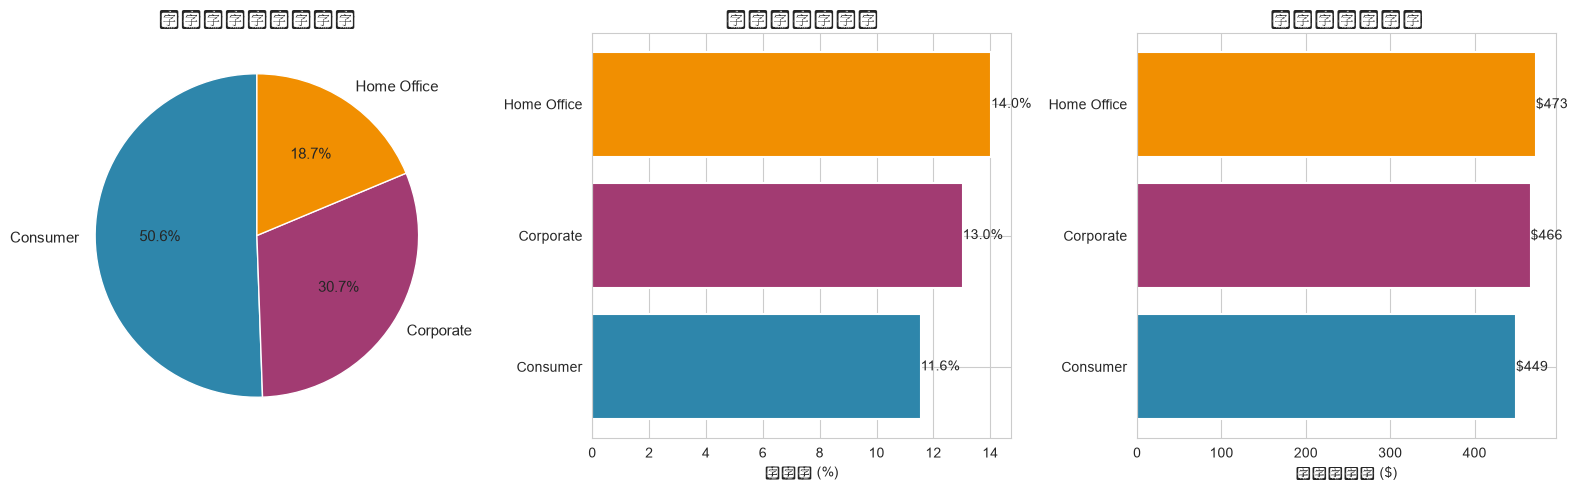

In [4]:
# 客户类型对比可视化
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 销售额占比
colors_pie = ['#2E86AB', '#A23B72', '#F18F01']
wedges, texts, autotexts = axes[0].pie(
    segment_stats['Total Sales'],
    labels=segment_stats['Segment'],
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    textprops={'fontsize': 11}
)
axes[0].set_title('客户类型销售额占比', fontsize=14, fontweight='bold')

# 利润率对比
bars = axes[1].barh(segment_stats['Segment'], segment_stats['Profit Margin'],
                    color=colors_pie, edgecolor='white', linewidth=1.5)
axes[1].set_xlabel('利润率 (%)')
axes[1].set_title('客户类型利润率', fontsize=14, fontweight='bold')
axes[1].bar_label(bars, fmt='%.1f%%', fontsize=10)

# 客单价对比
bars = axes[2].barh(segment_stats['Segment'], segment_stats['Avg Order Value'],
                    color=colors_pie, edgecolor='white', linewidth=1.5)
axes[2].set_xlabel('平均客单价 ($)')
axes[2].set_title('客户类型客单价', fontsize=14, fontweight='bold')
axes[2].bar_label(bars, fmt='$%.0f', fontsize=10)

plt.tight_layout()
plt.show()

## 2. 客户类型×品类分析

In [5]:
# 客户类型×品类交叉表
cross_segment_category = df.groupby(['Segment', 'Category']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index()

# 透视表
pivot_sales = cross_segment_category.pivot(index='Segment', columns='Category', values='Sales')
pivot_profit = cross_segment_category.pivot(index='Segment', columns='Category', values='Profit')

print('='*60)
print('📊 客户类型×品类销售额')
print('='*60)
print(pivot_sales.round(0).to_string())
print()
print('='*60)
print('📊 客户类型×品类利润')
print('='*60)
print(pivot_profit.round(0).to_string())

📊 客户类型×品类销售额
Category     Furniture  Office Supplies  Technology
Segment                                            
Consumer      391049.0         363952.0    406400.0
Corporate     229020.0         230676.0    246450.0
Home Office   121931.0         124418.0    183304.0

📊 客户类型×品类利润
Category     Furniture  Office Supplies  Technology
Segment                                            
Consumer        6991.0          56330.0     70798.0
Corporate       7585.0          40227.0     44167.0
Home Office     3875.0          25933.0     30490.0


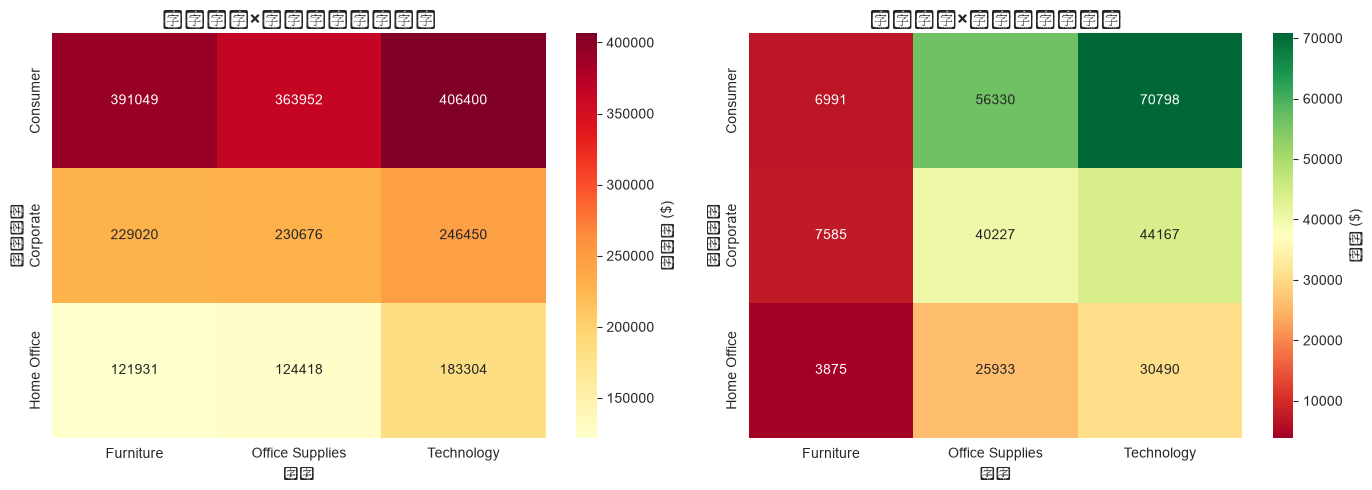

In [6]:
# 热力图可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 销售额热力图
sns.heatmap(pivot_sales, annot=True, fmt='.0f', cmap='YlOrRd',
            ax=axes[0], cbar_kws={'label': '销售额 ($)'})
axes[0].set_title('客户类型×品类销售额热力图', fontsize=14, fontweight='bold')
axes[0].set_ylabel('客户类型')
axes[0].set_xlabel('品类')

# 利润热力图
sns.heatmap(pivot_profit, annot=True, fmt='.0f', cmap='RdYlGn',
            ax=axes[1], cbar_kws={'label': '利润 ($)'})
axes[1].set_title('客户类型×品类利润热力图', fontsize=14, fontweight='bold')
axes[1].set_ylabel('客户类型')
axes[1].set_xlabel('品类')

plt.tight_layout()
plt.show()

## 3. 客户类型×区域分析

In [7]:
# 客户类型×区域交叉表
cross_segment_region = df.groupby(['Segment', 'Region']).agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

# 透视表
pivot_region_sales = cross_segment_region.pivot(index='Segment', columns='Region', values='Sales')
pivot_region_profit = cross_segment_region.pivot(index='Segment', columns='Region', values='Profit')

print('='*60)
print('📊 客户类型×区域销售额')
print('='*60)
print(pivot_region_sales.round(0).to_string())
print()
print('='*60)
print('📊 客户类型×区域利润')
print('='*60)
print(pivot_region_profit.round(0).to_string())

📊 客户类型×区域销售额
Region        Central      East     South      West
Segment                                            
Consumer     252031.0  350908.0  195581.0  362881.0
Corporate    157996.0  200409.0  121886.0  225855.0
Home Office   91213.0  127464.0   74255.0  136722.0

📊 客户类型×区域利润
Region       Central     East    South     West
Segment                                        
Consumer      8564.0  41191.0  26914.0  57451.0
Corporate    18704.0  23623.0  15215.0  34437.0
Home Office  12438.0  26709.0   4621.0  16530.0


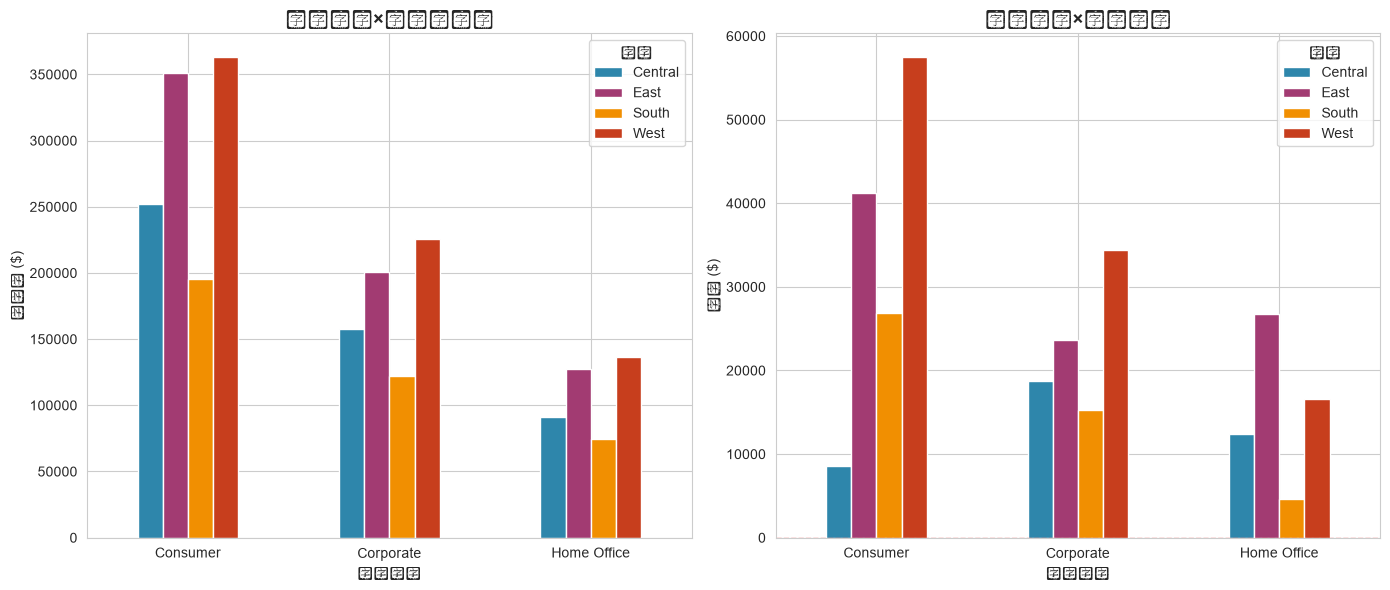

In [8]:
# 客户类型×区域可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 销售额分组柱状图
pivot_region_sales.plot(kind='bar', ax=axes[0], color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'])
axes[0].set_xlabel('客户类型')
axes[0].set_ylabel('销售额 ($)')
axes[0].set_title('客户类型×区域销售额', fontsize=14, fontweight='bold')
axes[0].legend(title='区域')
axes[0].tick_params(axis='x', rotation=0)

# 利润分组柱状图
pivot_region_profit.plot(kind='bar', ax=axes[1], color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'])
axes[1].set_xlabel('客户类型')
axes[1].set_ylabel('利润 ($)')
axes[1].set_title('客户类型×区域利润', fontsize=14, fontweight='bold')
axes[1].legend(title='区域')
axes[1].tick_params(axis='x', rotation=0)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

## 4. 客户消费金额分布

In [9]:
# 按客户聚合消费总额
customer_sales = df.groupby(['Customer ID', 'Customer Name', 'Segment']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index()
customer_sales.columns = ['Customer ID', 'Customer Name', 'Segment', 'Total Sales', 'Total Profit', 'Orders']
customer_sales = customer_sales.sort_values('Total Sales', ascending=False)

print('='*70)
print('📊 Top 15 客户')
print('='*70)
print(customer_sales.head(15).to_string(index=False))

📊 Top 15 客户
Customer ID      Customer Name     Segment  Total Sales  Total Profit  Orders
   SM-20320        Sean Miller Home Office    25043.050    -1980.7393       5
   TC-20980       Tamara Chand   Corporate    19052.218     8981.3239       5
   RB-19360       Raymond Buch    Consumer    15117.339     6976.0959       6
   TA-21385       Tom Ashbrook Home Office    14595.620     4703.7883       4
   AB-10105      Adrian Barton    Consumer    14473.571     5444.8055      10
   KL-16645       Ken Lonsdale    Consumer    14175.229      806.8550      12
   SC-20095       Sanjit Chand    Consumer    14142.334     5757.4119       9
   HL-15040       Hunter Lopez    Consumer    12873.298     5622.4292       6
   SE-20110       Sanjit Engle    Consumer    12209.438     2650.6769      11
   CC-12370 Christopher Conant    Consumer    12129.072     2177.0493       5
   TS-21370       Todd Sumrall   Corporate    11891.751     2371.7144       6
   GT-14710          Greg Tran    Consumer    11820.

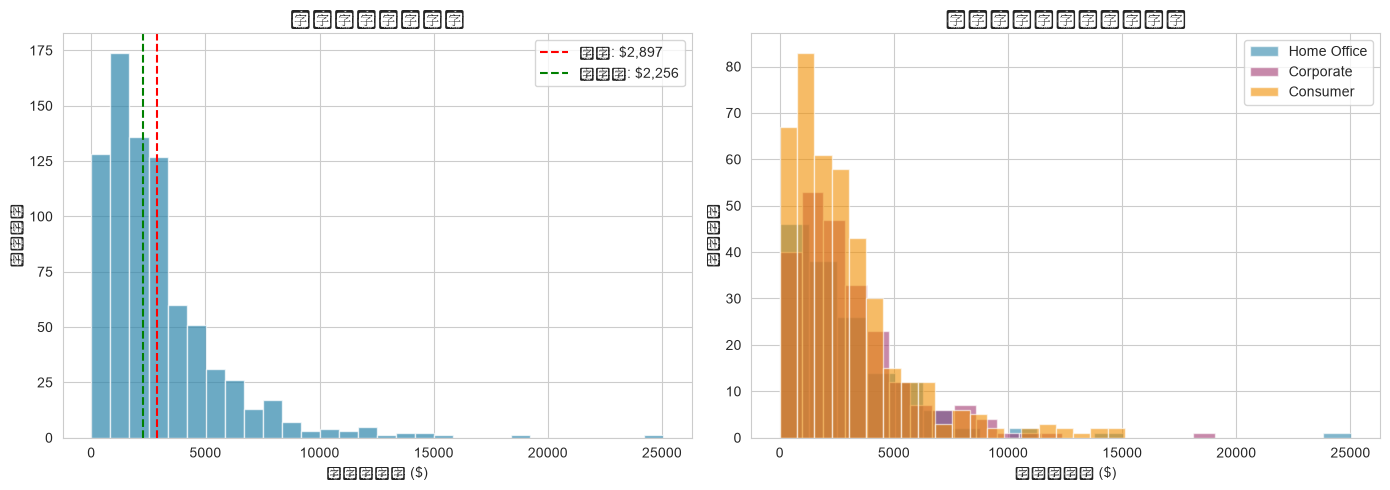

In [10]:
# 客户消费金额分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 总消费金额分布
axes[0].hist(customer_sales['Total Sales'], bins=30, color='#2E86AB', edgecolor='white', alpha=0.7)
axes[0].set_xlabel('总消费金额 ($)')
axes[0].set_ylabel('客户数量')
axes[0].set_title('客户消费金额分布', fontsize=14, fontweight='bold')
axes[0].axvline(customer_sales['Total Sales'].mean(), color='red', linestyle='--', 
                label=f'均值: ${customer_sales["Total Sales"].mean():,.0f}')
axes[0].axvline(customer_sales['Total Sales'].median(), color='green', linestyle='--',
                label=f'中位数: ${customer_sales["Total Sales"].median():,.0f}')
axes[0].legend()

# 按客户类型的消费分布
segments = customer_sales['Segment'].unique()
colors = ['#2E86AB', '#A23B72', '#F18F01']
for i, segment in enumerate(segments):
    data = customer_sales[customer_sales['Segment'] == segment]['Total Sales']
    axes[1].hist(data, bins=20, alpha=0.6, label=segment, color=colors[i], edgecolor='white')
axes[1].set_xlabel('总消费金额 ($)')
axes[1].set_ylabel('客户数量')
axes[1].set_title('各客户类型消费金额分布', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. 客户购买频次分析

📊 客户购买频次统计
    Segment  Avg Orders  Median Orders  Max Orders  Customer Count
   Consumer    6.322738            6.0          17             409
  Corporate    6.415254            6.0          13             236
Home Office    6.141892            6.0          12             148


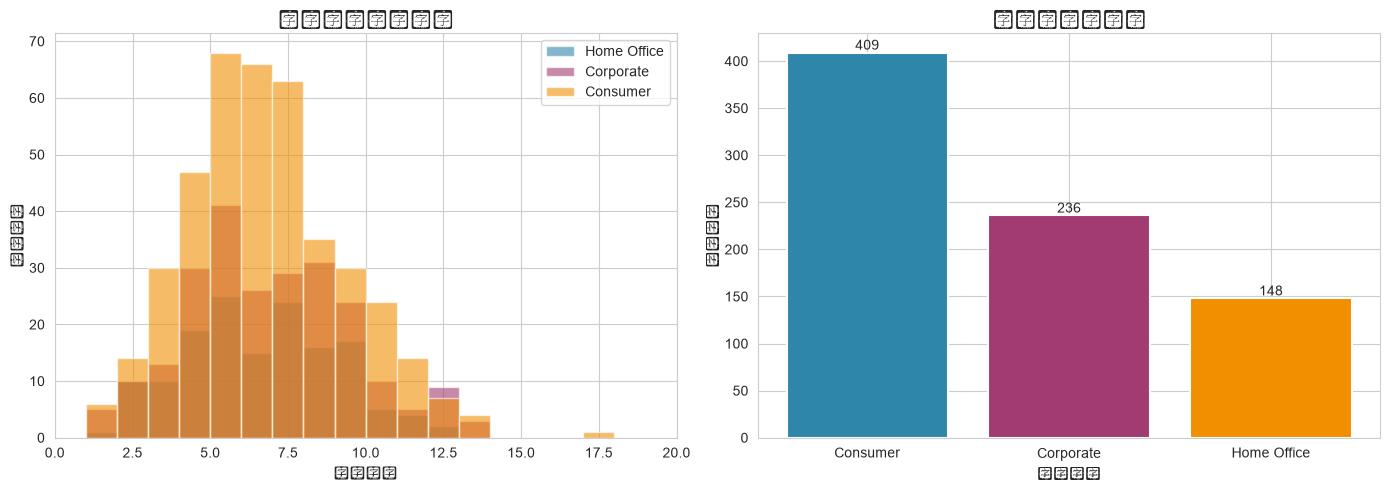

In [11]:
# 客户购买频次分布
order_freq = customer_sales.groupby('Segment').agg({
    'Orders': ['mean', 'median', 'max'],
    'Customer ID': 'count'
}).reset_index()
order_freq.columns = ['Segment', 'Avg Orders', 'Median Orders', 'Max Orders', 'Customer Count']

print('='*60)
print('📊 客户购买频次统计')
print('='*60)
print(order_freq.to_string(index=False))

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 按客户类型的订单量分布
for i, segment in enumerate(segments):
    data = customer_sales[customer_sales['Segment'] == segment]['Orders']
    axes[0].hist(data, bins=range(1, data.max()+2), alpha=0.6, label=segment, 
                 color=colors[i], edgecolor='white')
axes[0].set_xlabel('订单数量')
axes[0].set_ylabel('客户数量')
axes[0].set_title('客户购买频次分布', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 20)

# 客户数量对比
bars = axes[1].bar(order_freq['Segment'], order_freq['Customer Count'],
                   color=colors[:len(order_freq)], edgecolor='white', linewidth=1.5)
axes[1].set_xlabel('客户类型')
axes[1].set_ylabel('客户数量')
axes[1].set_title('各类型客户数量', fontsize=14, fontweight='bold')
axes[1].bar_label(bars, fontsize=10)

plt.tight_layout()
plt.show()

## 6. RFM 分析（简化版）

In [12]:
# RFM 分析
import datetime as dt

# 设置参考日期
reference_date = df['Order Date'].max() + pd.Timedelta(days=1)

# 计算 RFM 指标
rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (reference_date - x.max()).days,  # Recency
    'Order ID': 'nunique',  # Frequency
    'Sales': 'sum'  # Monetary
}).reset_index()

rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

# 评分（1-5分）
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# 合并客户信息
customer_info = df.groupby(['Customer ID', 'Customer Name', 'Segment']).size().reset_index()[['Customer ID', 'Customer Name', 'Segment']]
rfm = rfm.merge(customer_info, on='Customer ID', how='left')

print('='*60)
print('📊 RFM 分析结果（Top 15）')
print('='*60)
print(rfm.sort_values('Monetary', ascending=False).head(15).to_string(index=False))

📊 RFM 分析结果（Top 15）
Customer ID  Recency  Frequency  Monetary R_Score F_Score M_Score      Customer Name     Segment
   SM-20320       80          5 25043.050       3       2       5        Sean Miller Home Office
   TC-20980      400          5 19052.218       1       2       5       Tamara Chand   Corporate
   RB-19360       97          6 15117.339       3       3       5       Raymond Buch    Consumer
   TA-21385       70          4 14595.620       3       2       5       Tom Ashbrook Home Office
   AB-10105       42         10 14473.571       4       5       5      Adrian Barton    Consumer
   KL-16645       48         12 14175.229       4       5       5       Ken Lonsdale    Consumer
   SC-20095      350          9 14142.334       1       5       5       Sanjit Chand    Consumer
   HL-15040       44          6 12873.298       4       3       5       Hunter Lopez    Consumer
   SE-20110       10         11 12209.438       5       5       5       Sanjit Engle    Consumer
   CC-12370

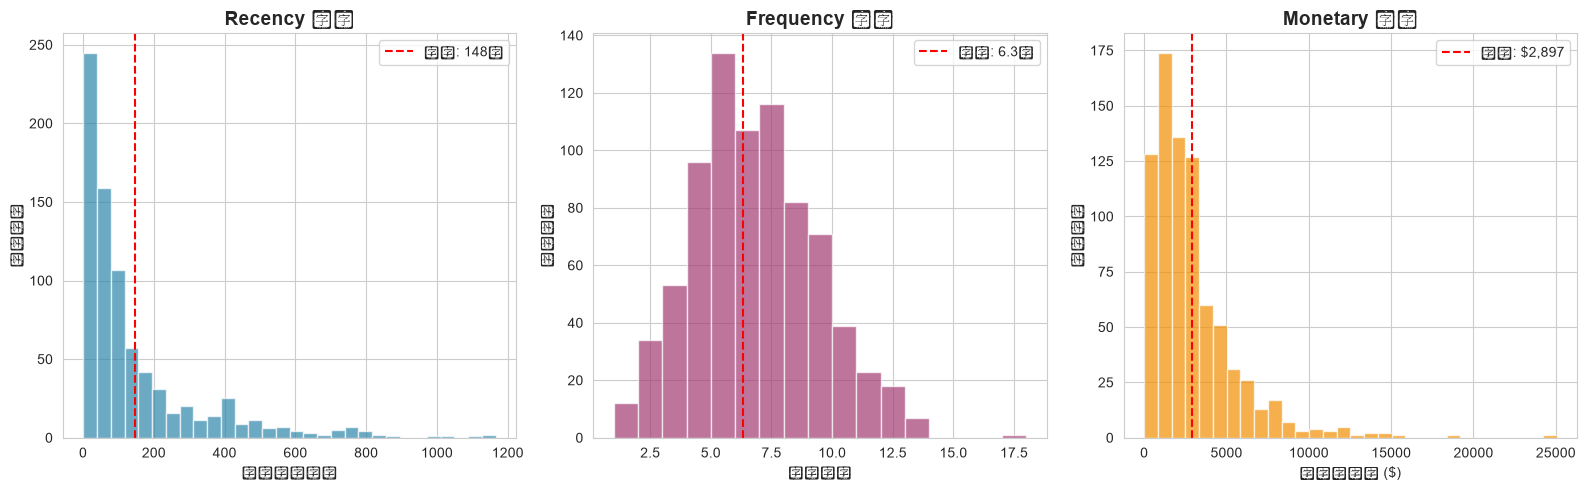

In [13]:
# RFM 可视化
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Recency 分布
axes[0].hist(rfm['Recency'], bins=30, color='#2E86AB', edgecolor='white', alpha=0.7)
axes[0].set_xlabel('最近购买天数')
axes[0].set_ylabel('客户数量')
axes[0].set_title('Recency 分布', fontsize=14, fontweight='bold')
axes[0].axvline(rfm['Recency'].mean(), color='red', linestyle='--', 
                label=f'均值: {rfm["Recency"].mean():.0f}天')
axes[0].legend()

# Frequency 分布
axes[1].hist(rfm['Frequency'], bins=range(1, rfm['Frequency'].max()+2), 
             color='#A23B72', edgecolor='white', alpha=0.7)
axes[1].set_xlabel('购买次数')
axes[1].set_ylabel('客户数量')
axes[1].set_title('Frequency 分布', fontsize=14, fontweight='bold')
axes[1].axvline(rfm['Frequency'].mean(), color='red', linestyle='--',
                label=f'均值: {rfm["Frequency"].mean():.1f}次')
axes[1].legend()

# Monetary 分布
axes[2].hist(rfm['Monetary'], bins=30, color='#F18F01', edgecolor='white', alpha=0.7)
axes[2].set_xlabel('总消费金额 ($)')
axes[2].set_ylabel('客户数量')
axes[2].set_title('Monetary 分布', fontsize=14, fontweight='bold')
axes[2].axvline(rfm['Monetary'].mean(), color='red', linestyle='--',
                label=f'均值: ${rfm["Monetary"].mean():,.0f}')
axes[2].legend()

plt.tight_layout()
plt.show()

## 7. 关键发现

In [14]:
# 计算关键指标
best_segment = segment_stats.iloc[0]
top_customer = customer_sales.iloc[0]

print('='*60)
print('💡 关键发现')
print('='*60)
print(f'\n🏆 最大客户类型：{best_segment["Segment"]}')
print(f'   - 销售额：${best_segment["Total Sales"]:,.2f}')
print(f'   - 占比：{best_segment["Sales Share"]:.1f}%')
print(f'   - 利润率：{best_segment["Profit Margin"]:.1f}%')
print(f'   - 客户数量：{best_segment["Customers"]}')

print(f'\n👑 最高价值客户：{top_customer["Customer Name"]}')
print(f'   - 总消费：${top_customer["Total Sales"]:,.2f}')
print(f'   - 总利润：${top_customer["Total Profit"]:,.2f}')
print(f'   - 订单数：{top_customer["Orders"]}')

print(f'\n📊 RFM 分析摘要：')
print(f'   - 平均 Recency：{rfm["Recency"].mean():.0f} 天')
print(f'   - 平均 Frequency：{rfm["Frequency"].mean():.1f} 次')
print(f'   - 平均 Monetary：${rfm["Monetary"].mean():,.2f}')

💡 关键发现

🏆 最大客户类型：Consumer
   - 销售额：$1,161,401.34
   - 占比：50.6%
   - 利润率：11.6%
   - 客户数量：409

👑 最高价值客户：Sean Miller
   - 总消费：$25,043.05
   - 总利润：$-1,980.74
   - 订单数：5

📊 RFM 分析摘要：
   - 平均 Recency：148 天
   - 平均 Frequency：6.3 次
   - 平均 Monetary：$2,896.85
